# TC 5033
## Deep Learning
## Fully Connected Deep Neural Networks using PyTorch
<br>

#### Activity 2a: Implementing a FC for ASL Dataset using PyTorch
<br>


- Objective

    The primary aim of this activity is to transition from using Numpy for network implementation to utilizing PyTorch, a powerful deep learning framework. You will be replicating the work you did for the ASL dataset in Activity 1b, but this time, you'll implement a your multi layer FC model using PyTorch.
    
- Instructions

    Review Previous Work: Begin by reviewing your Numpy-based Fully Connected Network for the ASL dataset from Activity 1b. Note the architecture, hyperparameters, and performance metrics for comparison.

    Introduce PyTorch: If you're new to PyTorch, take some time to familiarize yourself with its basic operations and syntax. You can consult the official documentation or follow online tutorials.

    Prepare the ASL Dataset: As before, download and preprocess the Kaggle ASL dataset. 

    Implement the Network: Design your network architecture tailored for the ASL dataset. Pay special attention to PyTorch modules like nn.Linear() and nn.ReLU().

    Train the Model: Implement the training loop, making use of PyTorch's autograd to handle backpropagation. Monitor metrics like loss and accuracy as the model trains.

    Analyze and Document: In Markdown cells, discuss the architecture choices, any differences in performance between the Numpy and PyTorch implementations, and insights gained from using a deep learning framework like PyTorch.

In [18]:
import numpy as np
import string
import pandas as pd
import matplotlib.pyplot as plt
import os
%matplotlib inline

#PyTorch stuff
import torch
import torch.nn as nn
import torch.nn.functional as F

# Solamente para usuarios de Jupyter Themes
#from jupyterthemes import jtplot
#jtplot.style(grid=False)

In [2]:
# DATA_PATH = '/media/pepe/DataUbuntu/Databases/asl_data/'
DATA_PATH = 'C:\\Users\\jfmag\\OneDrive\\Documentos\\Maestría\\Redes Neuronales\\asl_data\\asl_data'
train_df = pd.read_csv(os.path.join(DATA_PATH, 'sign_mnist_train.csv'))
valid_df = pd.read_csv(os.path.join(DATA_PATH, 'sign_mnist_valid.csv'))

### Always a good idea to explore the data

In [3]:
train_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,12,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


### Get training label data

In [4]:
y_train = np.array(train_df['label'])
y_val = np.array(valid_df['label'])
del train_df['label']
del valid_df['label']
x_train = train_df.values.astype(np.float32)
x_val = valid_df.values.astype(np.float32)

In [5]:
print(x_train.shape)
print(y_train.shape)

(27455, 784)
(27455,)


In [6]:
print(x_val.shape, y_val.shape)

(7172, 784) (7172,)


In [7]:
def split_val_test(x, y, pct=0.5, shuffle=True):
    assert x.shape[0] == y.shape[0], 'Number of samples x!= number samples y'
    total_samples = x.shape[0]
    if shuffle:
        idxs = np.arange(x.shape[0])
        np.random.shuffle(idxs)
        x = x[idxs]
        y = y[idxs]
        #return x_val, y_val, x_test, y_test
#         return x[:total_samples//2, :], y[:total_samples//2], x[total_samples//2:, :], y[total_samples//2:]
    return x[:int(total_samples*pct), :], y[:int(total_samples*pct)], x[int(total_samples*(pct)):, :], y[int(total_samples*(pct)):]
        

Aquí a comparacón del mío esta muy sintetizado, el método es mucho más simple y directo

In [8]:
x_val, y_val, x_test, y_test = split_val_test(x_val, y_val)

In [9]:
type(y_val)

numpy.ndarray

In [10]:
print(x_val.shape, y_val.shape)
print(x_test.shape, y_test.shape)

(3586, 784) (3586,)
(3586, 784) (3586,)


In [11]:
alphabet=list(string.ascii_lowercase)
alphabet.remove('j')
alphabet.remove('z')
print(len(alphabet))

24


### Normalise the data

In [12]:
def normalise(x_mean, x_std, x_data):
    return (x_data - x_mean) / x_std

In [13]:
x_mean = x_train.mean()
x_std = x_train.std()

x_train = normalise(x_mean, x_std, x_train)
x_val = normalise(x_mean, x_std, x_val)
x_test = normalise(x_mean, x_std, x_test)


In [14]:
x_train.mean(), x_train.std()

(np.float32(3.6268384e-06), np.float32(0.99999946))

In [15]:
def plot_number(image):
    plt.figure(figsize=(5,5))
    plt.imshow(image.squeeze(), cmap=plt.get_cmap('gray'))
    plt.axis('off')
    plt.show()

In [16]:
type(x_val)

numpy.ndarray

La imagen muestreada representa un: v


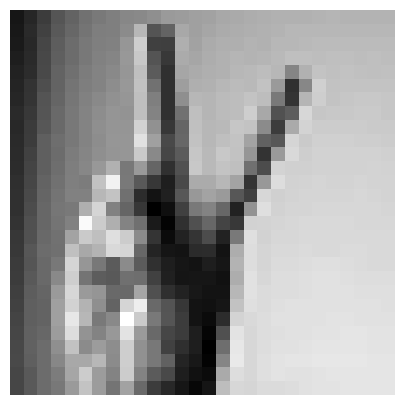

In [19]:
rnd_idx = np.random.randint(len(y_val))
# print(rnd_idx)
# print(y_val[rnd_idx])
print(f'La imagen muestreada representa un: {alphabet[y_val[rnd_idx]]}')
plot_number(x_val[rnd_idx].reshape(28,28))

### The model

$$z^1 = W^1 X + b^1$$

$$a^1 = ReLU(z^1) $$

$$z^2 = W^2 a^1 + b^2$$

$$\hat{y} = \frac{e^{z^{2_k}}}{\sum_j{e^{z_j}}}$$


$$ \mathcal{L}(\hat{y}^{i}, y^{i}) =  - y^{i}  \ln(\hat{y}^{i}) = -\ln(\hat{y}^i)$$


$$ \mathcal{J}(w, b) =  \frac{1}{num\_samples} \sum_{i=1}^{num\_samples}-\ln(\hat{y}^{i})$$

### Create minibatches

In [20]:
def create_minibatches(mb_size, x, y, shuffle = True):
    '''
    x  #muestras, 784
    y #muestras, 1
    '''
    assert x.shape[0] == y.shape[0], 'Error en cantidad de muestras'
    total_data = x.shape[0]
    if shuffle: 
        idxs = np.arange(total_data)
        np.random.shuffle(idxs)
        x = x[idxs]
        y = y[idxs]
        
    return ((x[i:i+mb_size], y[i:i+mb_size]) for i in range(0, total_data, mb_size))

In [21]:
for i, (x, y) in enumerate(create_minibatches(128,x_train, y_train)):
    print(i)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214


### Now the PyTorch part

In [22]:
x_train_tensor = torch.tensor(x_train.copy())
y_train_tensor = torch.tensor(y_train.copy())

x_val_tensor = torch.tensor(x_val.copy())
y_val_tensor = torch.tensor(y_val.copy())

x_test_tensor = torch.tensor(x_test.copy())
y_test_tensor = torch.tensor(y_test.copy())

Estos tensores son tensores matriciales (de orden 2) para el caso de las X, en el de las Ys son vectores ó lista de números (de orden 1), lo tengo en la tarea 1A
Piénsalo de la siguiente manera:

*`Escalar (Tensor de orden 0)`*: Es un único número. No tiene dimensiones. Piensa en un solo punto.

*`Vector (Tensor de orden 1)`*: Es una lista de números. Tiene una dimensión. Piensa en una línea de números.

*`Matriz (Tensor de orden 2)`*: Es una tabla o una cuadrícula de números. Tiene dos dimensiones (filas y columnas). Aquí es donde tu analogía de "arreglo es como una tabla" encaja perfectamente.

*`Tensor de orden 3`*: Es como un cubo de números, o una pila de tablas. Tiene tres dimensiones. Un ejemplo común es una imagen a color: no es solo una tabla de píxeles en blanco y negro, sino una tabla por cada canal de color (rojo, verde, azul), apiladas una detrás de otra. Así que tendrías 'alto' x 'ancho' x 'canales de color'.

Definición JFMP: similar a un diccionario de python anidado, sólo que aquí no tienes niveles porque está todo sobre el mismo 'eje'; como un cubo de información, no es un vector sólo es la coincidencia de esos 3 puntos, como una esfera flotando.

*`Tensores de orden superior (4, 5 o más)`*: Continúan esta generalización. Por ejemplo, un video podría ser visto como un tensor de 4 dimensiones: 'número de fotogramas' x 'alto' x 'ancho' x 'canales de color'.



In [23]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cpu


### Accuracy

In [24]:
def accuracy(model, x, y, mb_size):
    num_correct = 0
    num_total = 0
    cost = 0.
    model.eval() ###DUDA: Qué hace el eval()
    model = model.to(device=device)
    with torch.no_grad(): ##DUDA: torch.no_grad() es el que caclcula los graientes o ya no se calculan los gradientes
        '''
        mis dudas aquí son:
            entiendo que el loop parte de la función create_miibatches, y hasta ahí todo bien, pero por qué enumerate tiene un 1
            el tensor (xi,yi) sale de cada X y Y respectivamente
            por qué xi=xi.to(), si lo único que hace es validar que sea una matriz con el dtype y mandarla al CPU, enmi caso. Lo mimso para yi
            scores=model(xi) sólo envía una parte de los minibatches?
            _,pred, mi coco siempre es el _ antes de la variable, eso qué significa
            
        '''
        for mb, (xi, yi) in enumerate(create_minibatches(mb_size, x, y),1):
            xi = xi.to(device=device, dtype = torch.float32)
            yi = yi.to(device=device, dtype = torch.long)
            scores = model(xi) # mb_size, 10
            cost += (F.cross_entropy(scores, yi)).item()
            _, pred = scores.max(dim=1) #pred shape (mb_size )
            num_correct += (pred == yi.squeeze()).sum() # pred shape (mb_size), yi shape (mb_size, 1)
            num_total += pred.size(0)

        return cost/mb, float(num_correct)/num_total  

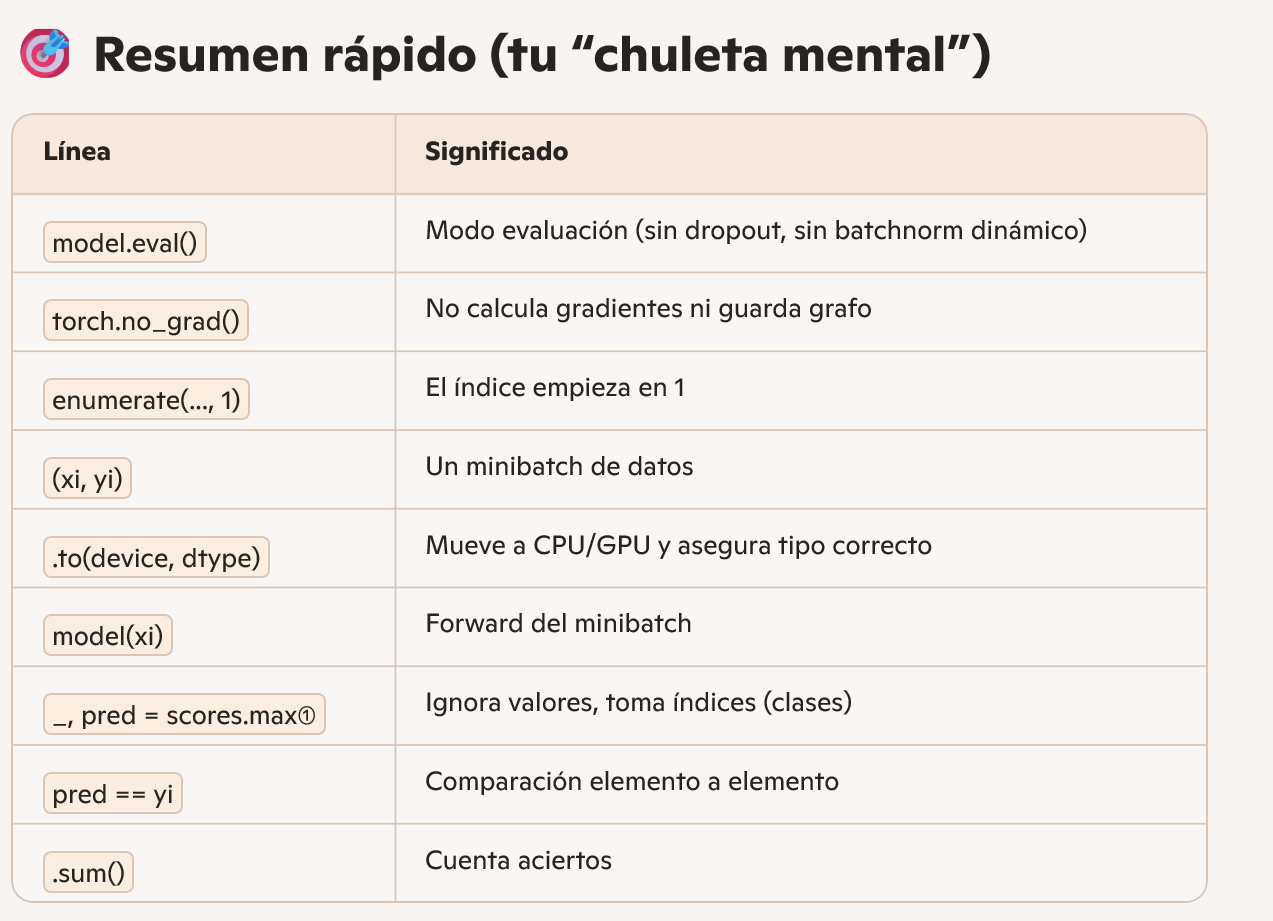


## Dudas sobre la función `accuracy`

### 1. ¿Qué hace exactamente `model.eval()`?
- ¿Qué cambia en el modelo cuando se llama a `eval()`?
- ¿Afecta los gradientes?
- ¿Por qué se usa en la fase de evaluación?

**Respuesta:**  
`model.eval()` pone al modelo en **modo evaluación**.  
Esto desactiva comportamientos que solo deben ocurrir durante el entrenamiento:

- `Dropout` deja de apagar neuronas.
- `BatchNorm` usa estadísticas fijas en lugar de estadísticas del minibatch.

No afecta los pesos ni el cálculo del forward.  
Tampoco desactiva gradientes (eso lo hace `torch.no_grad()`).


### 2. ¿`torch.no_grad()` calcula los gradientes o evita que se calculen?
- ¿Qué pasa dentro del bloque `with torch.no_grad():`?
- ¿Por qué se usa durante la evaluación?

**Respuesta:**  
- no calcula gradientes,
- no construye el grafo computacional,
- no guarda nada para backward,
- reduce el uso de memoria.
Es ideal para evaluación o inferencia.


### 3. ¿Por qué `enumerate(..., 1)` empieza en 1?
- ¿Qué diferencia hay entre `enumerate(iterable)` y `enumerate(iterable, 1)`?
- ¿Afecta la lógica del entrenamiento o solo es estético?

**Respuesta:**  
Respuesta:
enumerate(iterable, 1) hace que el contador inicie en 1 en lugar de 0.
Es solo estética; no afecta la lógica del entrenamiento.

### 4. ¿Qué representan `xi` y `yi` dentro del loop?
- ¿De dónde salen?
- ¿Qué shapes tienen?
- ¿Por qué se procesan minibatches?

**Respuesta:**  
Provienen de: for mb, (xi, yi) in enumerate(create_minibatches(...)):
- xi es un minibatch de inputs.
- yi es el minibatch de etiquetas.
Si mb_size = 32, entonces xi tiene 32 imágenes y yi tiene 32 etiquetas.

### 5. ¿Por qué se hace `xi = xi.to(device=device, dtype=torch.float32)`?
- ¿Qué significa mover un tensor al dispositivo?
- ¿Por qué se especifica el `dtype`?
- ¿Qué pasa si no lo hago?

**Respuesta:**  
Hace dos cosas:
- Mueve el tensor al dispositivo (CPU o GPU).
En tu caso, lo deja en CPU, pero el código queda listo para GPU.
- Asegura el tipo correcto:
- Inputs → float32
- Labels → long (requisito de cross_entropy)
Evita errores de tipo como: expected scalar type Long but found Float.

### 6. ¿`scores = model(xi)` procesa solo un minibatch?
- ¿Qué shape tiene `scores`?
- ¿Cómo se relaciona con `mb_size`?

**Respuesta:**  
Sí.
Si mb_size = 32, entonces:
- xi tiene shape (32, ...)
- scores tendrá shape (32, num_clases)
El modelo procesa un minibatch por iteración.


### 7. ¿Qué significa el guion bajo `_` en `_, pred = scores.max(dim=1)`?
- ¿Qué devuelve `scores.max(dim=1)`?
- ¿Por qué se ignora el primer valor?
- ¿Qué representa `pred`?

**Respuesta:**  
Respuesta:
scores.max(dim=1) devuelve:
- Los valores máximos (no los necesitas)
- Los índices donde ocurre el máximo (las clases predichas)
El guion bajo _ es una convención para “ignorar este valor”.
pred contiene las clases predichas.


### 8. ¿Qué hace esta línea?
```python
num_correct += (pred == yi.squeeze()).sum()

8.1 ¿Por qué se usa squeeze()?
yi a veces tiene shape (mb_size, 1).
pred tiene shape (mb_size,).
squeeze() convierte (mb_size, 1) → (mb_size,)
para que ambas dimensiones coincidan.

8.2 ¿Qué representa la comparación pred == yi?
Es una comparación elemento a elemento, devuelve un tensor booleano del tipo:
[True, False, True, ...]
Cada True significa “predicción correcta”.

8.3 ¿Qué cuenta .sum()?
Convierte los True en 1 y los False en 0, y luego los suma.
Es decir, cuenta cuántas predicciones fueron correctas en ese minibatch.



### Training Loop

In [26]:
def train(model, optimiser, mb_size, epochs=100):
    model = model.to(device=device)
    train_cost = 0.
    val_cost = 0.
    for epoch in range(epochs):
        train_correct_num  = 0.
        train_total = 0.
        train_cost_acum = 0
        for mb, (xi, yi) in enumerate(create_minibatches(mb_size, x_train_tensor, y_train_tensor), 1):
            model.train()
            xi = xi.to(device=device, dtype=torch.float32)
            yi = yi.to(device=device, dtype=torch.long)
            scores = model(xi)
            # funcion cost
            cost = F.cross_entropy(input= scores, target=yi.squeeze())
            optimiser.zero_grad()##Tengo duda de esta línea
            cost.backward()
            optimiser.step()
            
            train_correct_num += (torch.argmax(scores, dim=1) == yi.squeeze()).sum() ##explicar bien que hace el argmax
            train_total += scores.size(0)  
            
            train_cost_acum += cost.item()
        
        val_cost, val_acc = accuracy(model, x_val_tensor, y_val_tensor, mb_size)
        train_acc = float(train_correct_num)/train_total
        train_cost = train_cost_acum/mb
        if epoch%20 == 0:            
            print(f'Epoch:{epoch}, train cost: {train_cost:.6f}, val cost: {val_cost:.6f},'
                      f' train acc: {train_acc:.4f}, val acc: {val_acc:4f},'
                      f' lr: {optimiser.param_groups[0]["lr"]:.6f}')
    

# Guía de dudas sobre la función `train()` en PyTorch

Esta guía explica cada parte importante del ciclo de entrenamiento y las dudas más comunes.

---

## 1. ¿Qué hace `optimiser.zero_grad()`?

PyTorch **no borra los gradientes automáticamente**.  
Los gradientes se **acumulan** entre batches.

Por eso, el ciclo correcto es:

1. `optimiser.zero_grad()` → borra gradientes viejos  
2. `cost.backward()` → calcula gradientes nuevos  
3. `optimiser.step()` → actualiza los pesos  

Si no llamas a `zero_grad()`, el entrenamiento se vuelve incorrecto.

Piensa en zero_grad() como:

“Limpia la pizarra antes de escribir los gradientes del siguiente batch”.
---

## 2. ¿Qué hace `torch.argmax(scores, dim=1)`?

`argmax` devuelve **el índice del valor máximo** a lo largo de un eje.

En clasificación:

- `scores` tiene shape `(mb_size, num_clases)`
- cada fila es un vector de logits
- `argmax(dim=1)` devuelve la clase predicha para cada ejemplo

Ejemplo:


# ¿Qué es un logit? (Guía clara y profunda)

Un **logit** es el valor crudo que produce la red neuronal para cada clase **antes** de aplicar softmax.  
No es una probabilidad, no está normalizado y puede ser cualquier número real.

---

## ¿Por qué se llaman logits?

Porque representan log-odds:

\[
\text{logit}(p) = \log\left(\frac{p}{1 - p}\right)
\]

En redes neuronales no calculamos esta fórmula explícitamente,  
pero los valores cumplen el mismo rol:  
son puntajes sin restricciones que luego se convierten en probabilidades.

---

## ¿Por qué las redes producen logits y no probabilidades?

1. Los logits pueden ser cualquier número real.  
2. Softmax convierte logits en probabilidades.  
3. `F.cross_entropy` en PyTorch **ya incluye softmax internamente**,  
   por eso recibe logits directamente.

---

## Ejemplo de logits: scores = [1.2, -0.5, 3.7, 0.1]


- El mayor valor es 3.7  
- Está en la posición 2  
- La clase predicha es 2

---

## Relación entre logits y `argmax`

`torch.argmax(scores, dim=1)` devuelve el índice del logit más grande.  
Ese índice es la clase predicha.

Softmax no cambia el orden de los logits, por eso:

\[
\arg\max(\text{logits}) = \arg\max(\text{softmax(logits)})
\]

---

## Conexión con `cross_entropy`

`F.cross_entropy(scores, yi)` espera logits porque internamente hace:

- `log_softmax(scores)`
- `NLLLoss`

Esto es más estable y eficiente.







### Model using Sequential

In [27]:
#Instanciar modelo
# hidden1 = 100 
hidden = 200
lr = 1e-3
epochs = 100
mb_size = 128
model1 = nn.Sequential(nn.Linear(in_features=784, out_features=hidden), 
                       nn.Dropout(),
                       nn.ReLU(),
#                        nn.Linear(in_features=hidden1, out_features=hidden), nn.ReLU(),
                       nn.Linear(in_features=hidden, out_features=24))
# optimiser = torch.optim.SGD(model1.parameters(), lr=lr, momentum=0.9, weight_decay=1e-2)
optimiser = torch.optim.Adam(model1.parameters(), lr=lr, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimiser, 0.1, epochs=epochs, steps_per_epoch=215)

train(model1, optimiser, mb_size, epochs)

Epoch:0, train cost: 0.882608, val cost: 0.854436, train acc: 0.7237, val acc: 0.759342, lr: 0.004000
Epoch:20, train cost: 0.126763, val cost: 2.185638, train acc: 0.9690, val acc: 0.779420, lr: 0.004000
Epoch:40, train cost: 0.156167, val cost: 2.859697, train acc: 0.9688, val acc: 0.783324, lr: 0.004000
Epoch:60, train cost: 0.153701, val cost: 2.799648, train acc: 0.9683, val acc: 0.795594, lr: 0.004000
Epoch:80, train cost: 0.169592, val cost: 2.917391, train acc: 0.9666, val acc: 0.783045, lr: 0.004000


In [28]:
accuracy(model1, x_test_tensor, y_test_tensor, mb_size)[1]

0.7994980479643057

In [29]:
def predict(x, model):
    x = x.to(device=device, dtype = torch.float32)
    scores = model(x) # mb_size, 10
    _, pred = scores.max(dim=1) #pred shape (mb_size )
    return pred

La imagen muestreada representa un: u


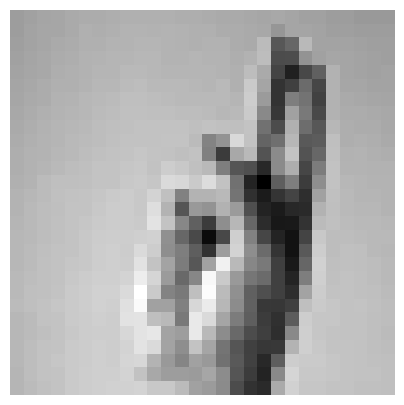

el valor predicho u


In [48]:
rnd_idx = np.random.randint(len(y_test))
print(f'La imagen muestreada representa un: {alphabet[y_test[rnd_idx]]}')
plot_number(x_test[rnd_idx].reshape(28,28))
pred=predict(x_test_tensor[rnd_idx].reshape(1, -1), model1)
print(f'el valor predicho {alphabet[pred]}')

# Diferencias entre capas lineales y capas no lineales

Esta tabla resume las diferencias fundamentales entre **capas lineales** y **capas no lineales** en redes neuronales.  
Es clave para entender por qué las redes profundas funcionan y por qué no basta con apilar capas lineales.

---

## Tabla comparativa

| Aspecto | Capas Lineales (`Linear`) | Capas No Lineales (`ReLU`, `Sigmoid`, `Tanh`, etc.) |
|--------|----------------------------|------------------------------------------------------|
| **Función principal** | Transformación lineal del tipo:  \[ y = Wx + b \] | Introducir no linealidad en la red |
| **Capacidad de representación** | Solo puede representar funciones lineales | Permiten representar funciones no lineales complejas |
| **Qué pasa si apilas varias** | Varias capas lineales seguidas equivalen a **una sola capa lineal** | Varias capas no lineales permiten aproximar funciones arbitrarias |
| **Rol en la red** | Mezclar, rotar, escalar y combinar características | Activar o apagar neuronas, introducir decisiones |
| **Derivadas** | Constantes (depende solo de W) | No constantes; cambian según la entrada |
| **Aprendizaje** | Aprende combinaciones lineales de features | Permite que la red aprenda patrones complejos |
| **Ejemplos típicos** | `nn.Linear`, `Conv2d` (también es lineal) | `ReLU`, `LeakyReLU`, `Sigmoid`, `Tanh`, `GELU` |
| **Sin ellas…** | La red sería equivalente a una regresión lineal gigante | La red no podría aprender fronteras de decisión complejas |

---

## Explicación conceptual

### 1. ¿Por qué las capas lineales solas no son suficientes?
Porque cualquier composición de funciones lineales sigue siendo lineal:

\[
W_3(W_2(W_1 x + b_1) + b_2) + b_3 = W'x + b'
\]

Sin no linealidad, una red profunda **no es más poderosa** que una sola capa.

---

### 2. ¿Por qué las capas no lineales son esenciales?
Porque permiten que la red:

- aprenda fronteras de decisión curvas,
- represente funciones complejas,
- modele relaciones no triviales entre variables,
- sea un aproximador universal.

---

### 3. Intuición geométrica
- **Lineal:** solo puede separar datos con una línea recta (o hiperplano).  
- **No lineal:** puede doblar el espacio, curvarlo, estirarlo, plegarlo.

---

### 4. Intuición práctica
Una red neuronal es básicamente:

\[
\text{(mezcla lineal)} \rightarrow \text{(no linealidad)} \rightarrow \text{(mezcla lineal)} \rightarrow \text{(no linealidad)} \rightarrow \dots
\]

Las capas lineales **combinan información**.  
Las capas no lineales **permiten tomar decisiones**.

---

# Resumen rápido

- Las capas lineales **transforman**.  
- Las capas no lineales **dan poder expresivo**.  
- Sin no linealidad, una red profunda es solo una regresión lineal disfrazada.  

# Comparación entre funciones de activación: ReLU, Sigmoid y Tanh

Esta tabla resume las diferencias fundamentales entre las funciones de activación
más comunes en redes neuronales: **ReLU**, **Sigmoid** y **Tanh**.

---

## Tabla comparativa

| Aspecto | ReLU | Sigmoid | Tanh |
|--------|------|---------|-------|
| **Fórmula** | `max(0, x)` | \( \sigma(x) = \frac{1}{1 + e^{-x}} \) | \( \tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}} \) |
| **Rango** | \([0, \infty)\) | \((0, 1)\) | \((-1, 1)\) |
| **Linealidad** | No lineal | No lineal | No lineal |
| **Derivada** | 0 si \(x < 0\), 1 si \(x > 0\) | \(\sigma(x)(1 - \sigma(x))\) | \(1 - \tanh^2(x)\) |
| **Ventajas** | Simple, rápida, evita saturación positiva | Interpretable como probabilidad | Centrada en cero, mejor que Sigmoid para gradientes |
| **Desventajas** | “Dying ReLU”: neuronas pueden quedar en 0 | Saturación → gradientes muy pequeños | También puede saturarse |
| **Uso típico** | Redes profundas, CNNs, MLPs | Última capa en clasificación binaria | Capas internas cuando se requiere centrado en cero |
| **Costo computacional** | Muy bajo | Medio | Medio |
| **Problema común** | Neuronas muertas | Vanishing gradients | Vanishing gradients (menos que Sigmoid) |

---

## Explicación conceptual

### ReLU
- Activa solo valores positivos.
- Es la más usada en redes profundas.
- Evita muchos problemas de saturación.
- Puede dejar neuronas permanentemente en cero si reciben gradientes negativos.

### Sigmoid
- Aplasta valores a \((0, 1)\).
- Ideal para **salidas de clasificación binaria**.
- No se usa en capas internas porque satura y produce gradientes muy pequeños.

### Tanh
- Similar a Sigmoid pero centrada en cero.
- Mejor para capas internas que Sigmoid.
- Aún puede saturarse en valores grandes.

---

## Intuición geométrica

- **ReLU**: corta el espacio en dos mitades y deja pasar solo lo positivo.  
- **Sigmoid**: aplasta todo a una curva suave entre 0 y 1.  
- **Tanh**: aplasta todo entre -1 y 1, simétrico alrededor de 0.

---

## Resumen rápido

- **ReLU** → rápida, eficiente, ideal para redes profundas.  
- **Sigmoid** → solo para salidas binarias.  
- **Tanh** → mejor que Sigmoid en capas internas, pero menos usada hoy que ReLU.


# Comparación entre capas lineales, capas no lineales y optimizadores (incluye ADAM)

Esta tabla resume las diferencias entre:
- Capas lineales
- Capas no lineales (funciones de activación)
- Optimizadores (como ADAM)

---

## Tabla comparativa

| Categoría | Qué es | Qué hace | Ejemplos | Cuándo se usa |
|----------|--------|----------|----------|----------------|
| **Capas lineales** | Transformaciones lineales | Mezclan, combinan y proyectan características mediante \( y = Wx + b \) | `nn.Linear`, `Conv2d` | En cualquier red para transformar representaciones |
| **Capas no lineales** | Funciones de activación | Introducen no linealidad; permiten aprender funciones complejas | `ReLU`, `Sigmoid`, `Tanh`, `GELU` | Entre capas lineales para dar poder expresivo |
| **Optimizadores** | Algoritmos de actualización | Ajustan los pesos usando gradientes | **ADAM**, SGD, RMSProp | Durante el entrenamiento para minimizar la pérdida |

---

## Detalle por categoría

### 1. Capas lineales
- Realizan transformaciones del tipo \( Wx + b \).
- No pueden modelar funciones no lineales por sí solas.
- Varias capas lineales seguidas equivalen a una sola capa lineal.

### 2. Capas no lineales
- Introducen decisiones y curvas en el espacio.
- Permiten que la red aprenda funciones complejas.
- Sin ellas, una red profunda sería solo una regresión lineal gigante.

### 3. Optimizadores (incluye ADAM)
- No transforman datos, transforman **pesos**.
- Usan gradientes para mover los parámetros hacia valores que minimizan la pérdida.
- **ADAM** combina Momentum + RMSProp:
  - Promedios móviles de gradientes
  - Ajuste adaptativo del learning rate por parámetro
- Es estable, rápido y funciona bien sin mucha calibración.

---

## Resumen rápido

- **Lineales** → combinan información.  
- **No lineales** → permiten aprender funciones complejas.  
- **Optimizadores (ADAM)** → ajustan los pesos para que la red aprenda.


# Comparación entre optimizadores: ADAM vs SGD vs RMSProp

Esta tabla resume las diferencias fundamentales entre los optimizadores más usados en deep learning:
**SGD**, **RMSProp** y **ADAM**.

---

## Tabla comparativa

| Aspecto | SGD | RMSProp | ADAM |
|--------|-----|---------|-------|
| **Nombre completo** | Stochastic Gradient Descent | Root Mean Square Propagation | Adaptive Moment Estimation |
| **Idea principal** | Actualiza pesos usando solo el gradiente actual | Ajusta el learning rate según la magnitud reciente de los gradientes | Combina Momentum + RMSProp |
| **Actualización básica** | \( w = w - \eta \cdot g \) | \( w = w - \frac{\eta}{\sqrt{E[g^2] + \epsilon}} g \) | \( w = w - \frac{\eta \cdot m_t}{\sqrt{v_t} + \epsilon} \) |
| **Usa momentum?** | Opcional | No | Sí (primer momento) |
| **Usa promedio de gradientes?** | No | Sí (cuadrados) | Sí (primer y segundo momento) |
| **Adaptativo por parámetro?** | No | Sí | Sí |
| **Velocidad de convergencia** | Lenta | Media | Rápida |
| **Estabilidad** | Sensible al learning rate | Más estable que SGD | Muy estable |
| **Cuándo usarlo** | Problemas simples, datasets pequeños | Redes profundas, RNNs | Casi cualquier red moderna |
| **Hiperparámetros típicos** | `lr=0.01` | `lr=0.001`, `rho=0.9` | `lr=0.001`, `beta1=0.9`, `beta2=0.999` |
| **Ventajas** | Simple, interpretable | Ajusta LR automáticamente | Rápido, robusto, funciona bien sin mucha calibración |
| **Desventajas** | Puede atascarse | Puede oscilar | Puede sobreajustar si no se regula |

---

## Explicación conceptual

### SGD
- Usa solo el gradiente actual.
- Es simple pero puede ser inestable.
- Requiere un learning rate bien ajustado.
- Puede quedarse atrapado en mínimos locales o valles planos.

### RMSProp
- Divide el gradiente por la raíz del promedio de gradientes recientes.
- Reduce el learning rate cuando los gradientes son grandes.
- Aumenta el learning rate cuando los gradientes son pequeños.
- Muy útil en RNNs y problemas con gradientes explosivos.

### ADAM
- Combina lo mejor de Momentum y RMSProp.
- Mantiene:
  - un promedio móvil de gradientes (primer momento),
  - un promedio móvil de gradientes al cuadrado (segundo momento).
- Ajusta automáticamente el learning rate por parámetro.
- Es el optimizador más usado en deep learning moderno.

---

## Resumen rápido

- **SGD** → simple, pero lento y sensible al learning rate.  
- **RMSProp** → adapta el learning rate según los gradientes recientes.  
- **ADAM** → rápido, estable y funciona bien en casi cualquier arquitectura.


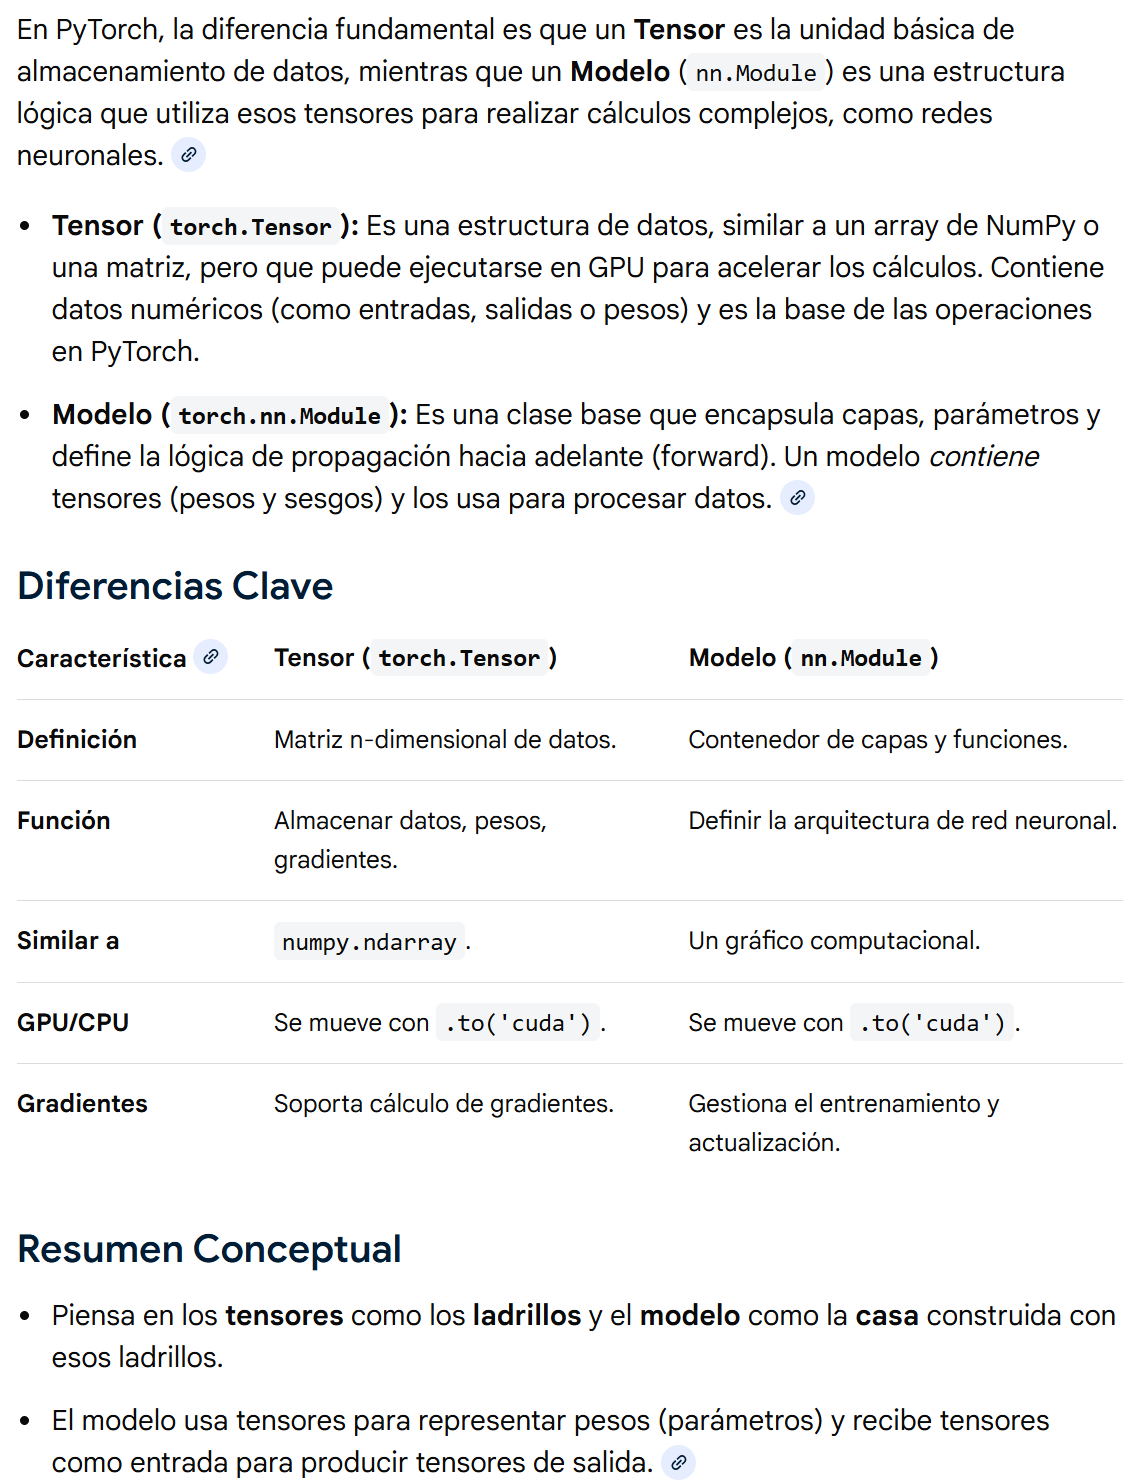

# Resumen de la arquitectura de PyTorch (versión José)

PyTorch se organiza alrededor de cinco componentes fundamentales:

---

## 1. Tensor
Es la unidad básica del sistema. Representa datos, parámetros y gradientes.  
Cuando `requires_grad=True`, el tensor participa en el grafo computacional y almacena gradientes durante el backward.  
Los parámetros entrenables del modelo son tensores especiales llamados `nn.Parameter`.

---

## 2. Module (nn.Module)
Es el orquestador del modelo.  
Contiene las capas (lineales y no lineales), organiza su orden y define el `forward`.  
También almacena los parámetros entrenables (`nn.Parameter`) que el optimizador modificará.  
El módulo define **cómo** se calcula el forward, pero no guarda las salidas del forward.

---

## 3. Grafo computacional
Se construye dinámicamente durante el forward.  
Cada operación crea un nodo que guarda:
- la función aplicada,
- los tensores padres,
- y los valores intermedios necesarios para derivar.

El grafo representa la ejecución del modelo sobre un batch específico y permite calcular gradientes automáticamente.

---

## 4. Autograd
Cuando se llama `loss.backward()`, recorre el grafo desde la salida hacia la entrada.  
Aplica la regla de la cadena en cada nodo y llena `param.grad` con los gradientes correspondientes.  
El autograd no crea los nodos: solo los usa para hacer el backward.

---

## 5. Optimizador
Recibe los parámetros entrenables del modelo y sus gradientes.  
Aplica una regla de actualización (SGD, Adam, etc.) para modificar los pesos y reducir la pérdida.  
Es el último paso del ciclo de entrenamiento.

---

### 📘 Tabla comparativa de criterion en PyTorch

| Pérdida | Tipo de problema | Entrada del modelo | Etiquetas | Notas |
|--------|------------------|--------------------|-----------|-------|
| **CrossEntropyLoss** | Clasificación multiclase | Logits (sin softmax) | Índices 0..C-1 | Combina softmax + NLLLoss. La más usada. |
| **NLLLoss** | Multiclase | Log-softmax | Índices 0..C-1 | Úsala solo si ya aplicaste log_softmax. |
| **BCELoss** | Binaria | Probabilidades (0–1) | 0 o 1 (float) | Requiere sigmoid antes. Menos estable. |
| **BCEWithLogitsLoss** | Binaria / multietiqueta | Logits | 0 o 1 (float) | Combina sigmoid + BCE. Muy estable. |
| **MSELoss** | Regresión | Valor continuo | Valor continuo | Error cuadrático medio. |
| **L1Loss** | Regresión | Valor continuo | Valor continuo | Más robusta a outliers. |
| **SmoothL1Loss** | Regresión | Valor continuo | Valor continuo | Mezcla L1 y L2. Usada en detección. |
| **TripletMarginLoss** | Métrico / embeddings | Embeddings | Embeddings | Face recognition, metric learning. |
